In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor


In [2]:
data = pd.read_csv('pone.0300127.s001.csv')
demographic_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Subject_Demographics/Demographics_09Oct2025.csv')
family_history = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Family_History_09Oct2025.csv')

In [3]:
data.head()

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,SCREENEDAM,ENROLL_AGE,INEXPAGE,AV133STDY,TAUSTDY,GAITSTDY,PISTDY,SV2ASTDY,NXTAUSTDY,DATELIG,PPMI_ONLINE_ENROLL,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,02/2011,Withdrew,10/2024,NaN,69.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,03/2011,Enrolled,09/2021,NaN,65.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,03/2011,Withdrew,10/2024,NaN,67.6,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,04/2011,Enrolled,01/2022,NaN,56.7,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,04/2011,Enrolled,01/2022,NaN,59.4,NaN,0.0,0.0,1.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0


In [4]:
df1=data[data['COHORT']==1]

In [5]:
df2=df1[(df1['ENROLL_STATUS']=='Enrolled') | (df1['ENROLL_STATUS']=='Complete') | (df1['ENROLL_STATUS']=='Withdraw Deceased')]

In [6]:
patient_data = df2[['PATNO','COHORT_DEFINITION','ENROLL_STATUS']]


In [7]:
demographic_data.head()

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,AFICBERB,ASHKJEW,BASQUE,BIRTHDT,SEX,CHLDBEAR,HOWLIVE,GAYLES,HETERO,BISEXUAL,PANSEXUAL,ASEXUAL,OTHSEXUALITY,HANDED,HISPLAT,RAASIAN,RABLACK,RAHAWOPI,RAINDALS,RANOS,RAWHITE,RAUNKNOWN,ORIG_ENTRY,LAST_UPDATE
0,IA86904,3000,TRANS,SCREEN,01/2011,0.0,0.0,0.0,12/1941,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,01/2011,2022-11-07 00:00:00.0
1,IA86905,3001,TRANS,SCREEN,02/2011,0.0,0.0,0.0,01/1946,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,02/2011,2022-11-07 00:00:00.0
2,IA86906,3002,TRANS,SCREEN,03/2011,0.0,0.0,0.0,08/1943,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
3,IA86907,3003,TRANS,SCREEN,03/2011,0.0,0.0,0.0,07/1954,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
4,IA86908,3004,TRANS,SCREEN,03/2011,0.0,0.0,0.0,11/1951,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0


In [8]:
import pandas as pd
import numpy as np


merged = patient_data.merge(demographic_data, on='PATNO', how='left')

race_cols = ['RAASIAN','RABLACK','RAHAWOPI','RAINDALS','RANOS','RAWHITE','RAUNKNOWN']
race_map = {
    'RAASIAN':   'Asian',
    'RABLACK':   'Black or African American',
    'RAHAWOPI':  'Native Hawaiian or Other Pacific Islander',
    'RAINDALS':  'American Indian or Alaska Native',
    'RANOS':     'Not Otherwise Specified',
    'RAWHITE':   'White',
    'RAUNKNOWN': 'Unknown'
}

def infer_race(row):
    flags = {col: (1 if pd.notna(row.get(col)) and float(row[col]) == 1.0 else 0) for col in race_cols}
    on_cols = [race_map[c] for c, v in flags.items() if v == 1]
    if len(on_cols) == 0:
        return 'Unknown'
    if len(on_cols) == 1:
        return on_cols[0]
    return 'Multiple'

merged['RACE'] = merged.apply(infer_race, axis=1)

Demo_df = merged[['PATNO', 'BIRTHDT', 'RACE', 'SEX']].reset_index(drop=True)
Demo_df.head()


,PATNO,BIRTHDT,RACE,SEX
0,3001,01/1946,White,1.0
1,3003,07/1954,White,0.0
2,3010,06/1964,White,1.0
3,3012,01/1953,White,1.0
4,3018,09/1951,White,0.0


In [9]:

anyfam_bin = (
    family_history['ANYFAMPD']
      .fillna(0)
      .gt(0)
      .astype(int)
)

anyfam_by_pat = (
    family_history.assign(ANYFAMPD_bin=anyfam_bin)
      .groupby('PATNO',as_index=False)['ANYFAMPD_bin']
      .max()
      .rename(columns={'ANYFAMPD_bin':'FamilyHistory'})
)

anyfam_by_pat.head(10)
data1 = Demo_df.merge(anyfam_by_pat, on='PATNO', how='left')
data1.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory
0,3001,01/1946,White,1.0,0.0
1,3003,07/1954,White,0.0,0.0
2,3010,06/1964,White,1.0,1.0
3,3012,01/1953,White,1.0,0.0
4,3018,09/1951,White,0.0,1.0


In [10]:
pd_diagnosis_history = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/PD_Diagnosis_History_22Oct2025.csv')

In [11]:
diagnosis=pd_diagnosis_history[['PATNO','PDDXDT','DXTREMOR','DXRIGID','DXBRADY','DXOTHSX','DOMSIDE']]
diagnosis.head()

,PATNO,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE
0,3001,04/2010,1.0,1.0,1.0,0.0,2.0
1,3002,02/2010,1.0,0.0,1.0,1.0,1.0
2,3003,03/2009,0.0,1.0,1.0,1.0,2.0
3,3005,NaN,NaN,NaN,NaN,NaN,NaN
4,3006,11/2010,1.0,1.0,1.0,0.0,2.0


In [12]:
data2=data1.merge(diagnosis, on ='PATNO', how = 'left')
data2.shape

(1173, 11)

In [13]:
dopamine_theraphy_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Initiation_of_Dopaminergic_Therapy_22Oct2025.csv')
dopamine_flag = (
    dopamine_theraphy_data.groupby('PATNO', as_index=False)['DOPTHERST']
    .max()
)
data3= data2.merge(dopamine_flag, on ='PATNO',how ='left')
data3.shape

(1173, 12)

In [14]:
montreal_cognitive_Ass = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Montreal_Cognitive_Assessment__MoCA__22Oct2025.csv')
montreal_cognitive_Ass['INFODT_parsed'] = pd.to_datetime(montreal_cognitive_Ass['INFODT'], format='%m/%Y', errors='coerce')
# mcascore = (
#     montreal_cognitive_Ass.sort_values(['PATNO', 'INFODT_parsed'])
#     .groupby('PATNO', as_index=False)
#     .tail(1)
# )

tmp = (
    montreal_cognitive_Ass
      .sort_values(['PATNO', 'INFODT_parsed'], ascending=[True, True])
      .assign(MCATOT_latest=lambda d: d.groupby('PATNO')['MCATOT'].ffill())
)

mcascore = (
    tmp.groupby('PATNO', as_index=False)
       .tail(1)[['PATNO', 'MCATOT_latest']]
       .rename(columns={'MCATOT_latest': 'MCATOT'})
)

data4 = data3.merge(mcascore, on='PATNO', how='left')
data4 = data3.merge(mcascore[['PATNO','MCATOT']], on ='PATNO', how='left')
data4.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0


In [15]:
freezing_fall = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Determination_of_Freezing_and_Falls_22Oct2025.csv')
freezing_fall['INFODT_parsed'] = pd.to_datetime(freezing_fall['INFODT'], format='%m/%Y', errors='coerce')

# latest_rows = (
#     freezing_fall
#     .sort_values(['PATNO', 'INFODT_parsed'])
#     .groupby('PATNO', as_index=False)
#     .tail(1)
# )
# latest_frz = latest_rows[['PATNO', 'FRZGT12M','FLNFR12M']].reset_index(drop=True)
# other_cols = [
#     'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
#     'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
#     'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST'
# ]

# agg_other = (
#     freezing_fall
#     .fillna(0)
#     .groupby('PATNO', as_index=False)[other_cols]
#     .max()
# )

# freeze_combined = latest_frz.merge(agg_other, on='PATNO', how='outer')
# data5 = data4.merge(freeze_combined, on='PATNO', how='left')
# print(data5.shape)



In [16]:
import pandas as pd

try:
    df = freezing_fall.copy()
except NameError:
    _ff_path = '/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Determination_of_Freezing_and_Falls_22Oct2025.csv'
    freezing_fall = pd.read_csv(_ff_path)
    freezing_fall['INFODT_parsed'] = pd.to_datetime(
        freezing_fall['INFODT'], format='%m/%Y', errors='coerce'
    )
    df = freezing_fall.copy()

if 'data4' not in globals():
    raise RuntimeError(
        'data4 is not defined — run upstream cells through the MoCA merge (builds data4) before this cell.'
    )

def pick_row_for_patient(patient_df):
    # sort once so "latest" is easy
    patient_df = patient_df.sort_values('INFODT_parsed')

    # 1. Most recent date for this patient
    latest_date = patient_df['INFODT_parsed'].max()
    latest_year = latest_date.year

    # 2. Which years does this patient have data for?
    years_present = set(patient_df['INFODT_parsed'].dt.year.dropna())

    # 3. Check continuous 3-year coverage: Y, Y-1, Y-2
    required_years = {latest_year, latest_year - 1, latest_year - 2}
    has_continuous_3yr = required_years.issubset(years_present)

    if has_continuous_3yr:
        # Keep only rows from those 3 required years
        recent_window = patient_df[
            patient_df['INFODT_parsed'].dt.year.isin(required_years)
        ]

        # Pick row with highest FRZGT12M, break ties by most recent date
        best_row = (
            recent_window
            .sort_values(
                by=['FLNFR12M', 'INFODT_parsed'],
                ascending=[False, False]
            )
            .iloc[0]
        )
    else:
        # Fall back to just the single latest row overall
        best_row = (
            patient_df
            .sort_values('INFODT_parsed', ascending=False)
            .iloc[0]
        )

    return best_row

# Apply per patient (avoid groupby.apply: pandas 2.2+ may drop PATNO from chunks → KeyError)
best_rows = pd.DataFrame(
    [pick_row_for_patient(g) for _, g in df.fillna(0).groupby('PATNO')]
).reset_index(drop=True)
best_rows=best_rows[['PATNO', 'FRZGT12M','FLNFR12M',
    'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
    'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
    'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST','INFODT_parsed']]
data5 = data4.merge(best_rows, on ='PATNO', how='left')
data5.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01


In [17]:
scopa = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/SCOPA-AUT_22Oct2025.csv')
scopa['INFODT_parsed'] = pd.to_datetime(scopa['INFODT'], format='%m/%Y', errors='coerce')

scopa_aut = (
    scopa.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
scopa_latest=scopa_aut[['PATNO','SCAU14','SCAU16']].reset_index(drop=True)
data6=data5.merge(scopa_latest, on='PATNO', how='left')
data6.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0


In [18]:
neuro_QoL=pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_22Oct2025.csv')


neuro_QoL['INFODT_parsed'] = pd.to_datetime(neuro_QoL['INFODT'], format='%m/%Y', errors='coerce')

latest_rows = (
    neuro_QoL.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
nqmob37_latest = latest_rows[['PATNO', 'NQMOB37','NQMOB30','NQMOB26','NQMOB32','NQMOB33','NQMOB31','NQMOB28']].reset_index(drop=True)
data7=data6.merge(nqmob37_latest, on ='PATNO', how='left')
data7.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0


In [19]:
geriatric_depression = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Geriatric_Depression_Scale__Short_Version__22Oct2025.csv')
flip_cols = ['GDSSATIS', 'GDSGSPIR', 'GDSHAPPY', 'GDSALIVE', 'GDSENRGY']

for c in flip_cols:
    geriatric_depression[c] = geriatric_depression[c].where(geriatric_depression[c].isna(), 1 - geriatric_depression[c].astype(float))

sum_cols = [
    'GDSSATIS','GDSDROPD','GDSEMPTY','GDSBORED','GDSGSPIR','GDSAFRAD',
    'GDSHAPPY','GDSHLPLS','GDSHOME','GDSMEMRY','GDSALIVE','GDSWRTLS',
    'GDSENRGY','GDSHOPLS','GDSBETER'
]

geriatric_depression['Total Depression Score'] = geriatric_depression[sum_cols].sum(axis=1, skipna=True).astype(float)
geriatric_depressionScore = (
    geriatric_depression.groupby('PATNO', as_index=False)['Total Depression Score']
    .max()
)
# geriatric_depression = geriatric_depression[geriatric_depression['EVENT_ID']=='BL']
scale_score = ['PATNO', 'Total Depression Score']
data8=data7.merge(geriatric_depressionScore[scale_score], on ='PATNO', how='left')
data8.head(5)

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [20]:
data8.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [21]:
MDS_UPDRS=pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_IV__Motor_Complications_22Oct2025.csv')


MDS_UPDRS['INFODT_parsed'] = pd.to_datetime(MDS_UPDRS['INFODT'], format='%m/%Y', errors='coerce')

latest_rows_updrs = (
    MDS_UPDRS.groupby('PATNO', as_index=False)['NP4TOT']
    .max()
)
MDS_UPDRS_latest = latest_rows_updrs[['PATNO', 'NP4TOT']].reset_index(drop=True)
data9=data8.merge(MDS_UPDRS_latest, on ='PATNO', how='left')
data9.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0


In [22]:
vital_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Vital_Signs_08Oct2025.csv')

vital_data['DATE'] = pd.to_datetime(vital_data['INFODT'], format='%m/%Y', errors='coerce')

vital_data = vital_data.sort_values(['PATNO', 'DATE'], ascending=[True, False])

valid = vital_data[vital_data['HTCM'].notna() & vital_data['WGTKG'].notna()].copy()

valid['height_m'] = valid['HTCM'] / 100.0
valid['BMI'] = valid['WGTKG'] / (valid['height_m'] ** 2)

latest_valid = (
    valid.groupby('PATNO', as_index=False)
         .first()[['PATNO', 'DATE', 'WGTKG', 'HTCM', 'BMI']]
)

all_patients = vital_data[['PATNO']].drop_duplicates()
result = all_patients.merge(latest_valid, on='PATNO', how='left')
result_latest = result[['PATNO', 'BMI']].reset_index(drop=True)

data10=data9.merge(result_latest, on ='PATNO', how='left')
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT,BMI
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574


In [23]:
data10 = data10.rename(columns={
    'PATNO': 'PATNO',
    'PDDXDT': "Date of Parkinson's disease diagnosis",
    'DXTREMOR': 'Resting Tremor present at diagnosis?',
    'DXRIGID': 'Rigidity present at diagnosis?',
    'DXBRADY': 'Bradykinesia present at diagnosis?',
    'DXOTHSX': 'Postural instability present at dx?',
    'DOMSIDE': 'Side predominantly affected at onset',
    'DOPTHERST':'Dopaminergic therapy started for participant',
    'MCATOT':'MoCA Total Score',
    'FRZGT12M': 'Freezing of gait in past 12 months',
    'FLNFR12M': 'Falls not rel to freezing past 12 months',
    'INJFRHIP': 'Fracture of hip or lower limb',
    'INJFRUE':  'Fracture of upper extremity',
    'INJFRSKL': 'Skull fracture',
    'INJFROTH': 'Other fracture',
    'HINJNOLC': 'Head injury without loss of consciousness',
    'HINJLOC2': 'Head injury with loss of consciousness',
    'INJSTCH':  'Laceration requiring sutures (stitches)',
    'INJOTH':   'Other Injury',
    'FLLDRVIS': 'Fall resulted in outpatient visit to a healthcare provider',
    'FLLERVIS': 'Fall resulted in ER visit',
    'FLLHOSP':  'Fall resulted in hospitalization',
    'FLLSURG':  'Fall resulted in surgery',
    'FLLINST':  'Fall resulted in institutionalization',
    'SCAU14':'lightheaded after standing',
    'SCAU16': 'fainted',
    'NQMOB37': 'Able to get on and off toilet',
    'NQMOB30': 'Able to step up and down curbs',
    'NQMOB26': 'Able to get in and out of a car',
    'NQMOB32': 'Able to get out of bed into chair',
    'NQMOB33':'Able to run errands and shop',
    'NQMOB31':'Able to get off floor without help',
    'NQMOB28':'Able to go for a walk of at least 15 min',
    'NP4TOT': 'MDS-UPDRS PartIV score',
    
    
})

In [24]:
data10['Date of Parkinson\'s disease diagnosis'] = pd.to_datetime(data10['Date of Parkinson\'s disease diagnosis'], format='%m/%Y', errors='coerce')

# Compute number of years from diagnosis date to today
today = pd.Timestamp.today()
data10['No_of_years'] = (today.year - data10['Date of Parkinson\'s disease diagnosis'].dt.year)
data10['No_of_years'] = data10['No_of_years']
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,Fracture of hip or lower limb,Fracture of upper extremity,Skull fracture,Other fracture,Head injury without loss of consciousness,Head injury with loss of consciousness,Laceration requiring sutures (stitches),Other Injury,Fall resulted in outpatient visit to a healthcare provider,Fall resulted in ER visit,Fall resulted in hospitalization,Fall resulted in surgery,Fall resulted in institutionalization,INFODT_parsed,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594,15
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14


In [25]:
cols = [
    'Freezing of gait in past 12 months','Falls not rel to freezing past 12 months','Fracture of hip or lower limb',
    'Fracture of upper extremity','Skull fracture','Other fracture','Head injury without loss of consciousness','Head injury with loss of consciousness','Laceration requiring sutures (stitches)',
    'Other Injury','Fall resulted in outpatient visit to a healthcare provider','Fall resulted in ER visit','Fall resulted in hospitalization','Fall resulted in surgery','Fall resulted in institutionalization'
]

# data9[cols].isna().all(axis=1).sum()

data10.isna().sum()

PATNO                                                           0
BIRTHDT                                                         0
RACE                                                            0
SEX                                                             0
FamilyHistory                                                   1
Date of Parkinson's disease diagnosis                           0
Resting Tremor present at diagnosis?                            0
Rigidity present at diagnosis?                                  0
Bradykinesia present at diagnosis?                              0
Postural instability present at dx?                             1
Side predominantly affected at onset                            0
Dopaminergic therapy started for participant                  180
MoCA Total Score                                                0
Freezing of gait in past 12 months                             83
Falls not rel to freezing past 12 months                       83
Fracture o

In [26]:
cols = [
    'FamilyHistory',
    'Postural instability present at dx?',
    'Dopaminergic therapy started for participant',
    'Freezing of gait in past 12 months',
    'Falls not rel to freezing past 12 months',
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
    'lightheaded after standing', 'fainted',
    'MDS-UPDRS PartIV score',
    'BMI',
    'MoCA Total Score',
]

data10[cols] = data10[cols].fillna(0)
data10.isna().sum()

PATNO                                                          0
BIRTHDT                                                        0
RACE                                                           0
SEX                                                            0
FamilyHistory                                                  0
Date of Parkinson's disease diagnosis                          0
Resting Tremor present at diagnosis?                           0
Rigidity present at diagnosis?                                 0
Bradykinesia present at diagnosis?                             0
Postural instability present at dx?                            0
Side predominantly affected at onset                           0
Dopaminergic therapy started for participant                   0
MoCA Total Score                                               0
Freezing of gait in past 12 months                             0
Falls not rel to freezing past 12 months                       0
Fracture of hip or lower 

In [27]:
missing_patnos = set(data8['PATNO']) - set(MDS_UPDRS_latest['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)


Missing patient count: 152
Missing PATNOs: {215045, 101384, 213005, 216592, 170519, 312859, 224286, 241189, 223275, 292908, 250929, 245300, 297536, 182340, 293445, 179784, 329289, 40012, 293454, 212049, 139859, 325718, 195159, 274520, 292962, 238181, 101482, 293487, 423535, 151669, 236149, 301695, 236672, 301697, 238720, 147077, 110219, 101516, 182925, 103566, 174735, 317067, 168082, 163478, 100001, 157360, 221362, 293044, 179894, 311993, 407230, 298184, 242895, 293075, 310998, 175837, 343776, 101092, 217828, 228580, 170727, 167657, 357613, 347374, 429297, 252146, 182515, 311540, 251125, 173814, 319735, 115448, 147191, 243963, 244480, 240385, 293632, 293633, 219409, 111383, 121624, 112926, 177956, 216360, 408874, 216875, 245550, 113460, 172854, 293703, 313162, 245591, 253783, 147294, 313702, 114534, 212839, 239462, 293740, 173420, 133486, 313715, 101756, 172413, 141696, 317824, 243589, 293767, 5000, 143757, 5006, 5013, 5014, 5015, 5016, 5017, 187800, 243612, 312222, 293793, 158117, 292

In [28]:
missing_patnos = set(data3['PATNO']) - set(mcascore['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)

Missing patient count: 0
Missing PATNOs: set()


In [29]:
data10['Falls not rel to freezing past 12 months'].value_counts()

Falls not rel to freezing past 12 months
0.0    725
1.0    320
2.0    112
3.0     11
4.0      5
Name: count, dtype: int64

In [30]:
data10.to_csv('Final_data_injuries.csv',index=False)

In [31]:
injury_cols = [
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'INFODT_parsed',
]
data11 = data10.copy()
data11['Fall related consequences'] = (data11[injury_cols].eq(1).any(axis=1)).astype(int)
data11 = data11.drop(columns=injury_cols)
data11.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,Fall related consequences
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,1
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,1
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,1


In [32]:
data12=data11.drop(columns=['Fall related consequences'])

In [33]:
#Final data
data12.to_csv('Final_data1.csv',index=False)

## Cleaning some of the columns and adding more features


In [34]:
data = pd.read_csv('Final_data1.csv')
data = data.rename(columns={'Freezing of gait in past 12 months': 'Freezing of gait in past 36 months', 'Falls not rel to freezing past 12 months':'Falls not rel to freezing past 36 months'})
col = 'Falls not rel to freezing past 36 months'

# Combining fall class 3,4 to 2
data.loc[data[col] > 2, col] = 2

# Removing outliers in BMI
data['BMI'] = data['BMI'].apply(lambda x: 25.05736 if x > 123 else x)
data_1 = data[data['BMI'] <= 50]

#No BMI values
data_1=data_1[data_1['BMI']>0]

### MDS-UPDRS Part I score

Loads max `NP1RTOT` per `PATNO`, renames to **`MDS-UPDRS Part I Score`**, merges into cleaned `data1`.


In [35]:
updrs1 = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_26Jan2026.csv')
latest_rows_updrs1 = (
    updrs1.groupby('PATNO', as_index=False)['NP1RTOT']
    .max()
)
updrs1_latest = (
    latest_rows_updrs1[['PATNO', 'NP1RTOT']]
    .reset_index(drop=True)
    .rename(columns={'NP1RTOT': 'MDS-UPDRS Part I Score'})
)
data_1 = data_1.merge(updrs1_latest, on='PATNO', how='left')
data_1.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,10.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,5.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,13.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0


In [36]:
#Adding 
updrs1_ques = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_26Jan2026.csv')
updrs1_ques['INFODT_parsed'] = pd.to_datetime(updrs1_ques['INFODT'], format='%m/%Y', errors='coerce')

updrs1_ques_sorted = updrs1_ques.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

updrs1_ques_latest = (
    updrs1_ques_sorted.groupby('PATNO', as_index=False)
    .agg(
        Daytime_Sleepiness=('NP1SLPD', latest_non_nan),
        Urinary_Problems=('NP1URIN', latest_non_nan)
    )
)
data_2 = data_1.merge(updrs1_ques_latest, on='PATNO', how='left')
data_2.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,10.0,2.0,4.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,5.0,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,13.0,2.0,2.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0


In [37]:
gait = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')
gait['INFODT_parsed'] = pd.to_datetime(gait['INFODT'], format='%m/%Y', errors='coerce')

gait_sorted = gait.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

gait_latest = (
    gait_sorted.groupby('PATNO', as_index=False)
    .agg(
        Gait=('NP3GAIT', latest_non_nan),
        Postural_Stability=('NP3PSTBL', latest_non_nan),
        Hoehn_And_Yahr_Stage=('NHY', latest_non_nan)
    )
)
data_3 = data_2.merge(gait_latest, on='PATNO', how='left')
data_3.head()

/var/folders/y4/fkn560k16c3__twnyy0m4jxr0000gn/T/ipykernel_2705/724118174.py:1: DtypeWarning: Columns (0: DBSOFFTM, 1: DBSONTM) have mixed types. Specify dtype option on import or set low_memory=False.
  gait = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems,Gait,Postural_Stability,Hoehn_And_Yahr_Stage
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,10.0,2.0,4.0,1.0,1.0,2.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,5.0,2.0,0.0,1.0,0.0,2.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,13.0,2.0,2.0,1.0,1.0,3.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0,1.0,0.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0,101.0,101.0,5.0


In [38]:
postht = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Other_Clinical_Features_25Feb2026.csv')
postht['INFODT_parsed'] = pd.to_datetime(postht['INFODT'], format='%m/%Y', errors='coerce')

postht_sorted = postht.sort_values(['PATNO', 'INFODT_parsed'])

postht_latest = (
    postht_sorted.groupby('PATNO', as_index=False)
    .agg(
        Postural_hypotension=('FEATPOSHYP', latest_non_nan)
    )
)
data_4 = data_3.merge(postht_latest, on='PATNO', how='left')
data_4.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems,Gait,Postural_Stability,Hoehn_And_Yahr_Stage,Postural_hypotension
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,10.0,2.0,4.0,1.0,1.0,2.0,1.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,5.0,2.0,0.0,1.0,0.0,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,13.0,2.0,2.0,1.0,1.0,3.0,0.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0,1.0,0.0,2.0,0.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0,101.0,101.0,5.0,2.0


In [39]:
# Convert "MM/YYYY" to a proper date (set day=1)
data_4['BIRTHDT'] = pd.to_datetime(data_4['BIRTHDT'], format='%m/%Y')

today = pd.to_datetime('today')

# Compute age manually
data_4['Age'] = (today.year - data_4['BIRTHDT'].dt.year) - \
              ((today.month < data_4['BIRTHDT'].dt.month).astype(int))

#Gaussian weight to able to features\
Value	Meaning	Gaussian Weight (σ=1.2)\
0	Fully able	0.18\
1	Mostly able	0.53\
2	Moderate difficulty	0.91\
3	Moderate difficulty	0.91\
4	Mostly unable	0.53\
5	Fully unable	0.18\

In [40]:
import numpy as np

def gaussian_weight(x, mu=2.5, sigma=1.2):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

able_cols = [
    'Able to get on and off toilet',
    'Able to step up and down curbs',
    'Able to get in and out of a car',
    'Able to get out of bed into chair',
    'Able to run errands and shop',
    'Able to get off floor without help',
    'Able to go for a walk of at least 15 min'
]

# Apply gaussian weight to each value and sum across features
data_4['able_weighted_score'] = (
    data_4[able_cols]
    .apply(lambda col: col.apply(lambda x: gaussian_weight(x) if pd.notna(x) else np.nan))
    .sum(axis=1)
)


In [51]:
# Statistical testing for categorical variables to see if all features are significant to the output variable
import pandas as pd
from scipy.stats import chi2_contingency

# Define your categorical variables
cat_cols = [
    'FamilyHistory',
    'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant',
       'Freezing of gait in past 36 months',
       'Falls not rel to freezing past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min','Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage',
       'Postural_hypotension'
]

target = 'Falls not rel to freezing past 36 months'

results = []

for col in cat_cols:
    # Build contingency table (drop NaNs so test doesn’t fail)
    table = pd.crosstab(data_4[col], data_4[target])
    
    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(table)
        results.append({'Variable': col, 'Chi2': chi2, 'p-value': p})
    else:
        results.append({'Variable': col, 'Chi2': None, 'p-value': None})

chi_df = pd.DataFrame(results).sort_values('p-value', ascending=True)
chi_df


,Variable,Chi2,p-value
8,Falls not rel to freezing past 36 months,2336.000000,0.000000e+00
7,Freezing of gait in past 36 months,377.524597,1.196989e-76
15,Able to run errands and shop,302.682267,4.212614e-59
14,Able to get out of bed into chair,270.472235,2.659500e-52
16,Able to get off floor without help,268.519730,6.859459e-52
11,Able to get on and off toilet,256.189477,2.708587e-49
12,Able to step up and down curbs,240.077971,6.597822e-46
17,Able to go for a walk of at least 15 min,227.768334,2.522109e-43
13,Able to get in and out of a car,206.219242,8.129359e-39
22,Hoehn_And_Yahr_Stage,193.233771,8.104537e-35


In [50]:
data_4.columns

Index(['PATNO', 'BIRTHDT', 'RACE', 'SEX', 'FamilyHistory',
       'Date of Parkinson's disease diagnosis',
       'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'Falls not rel to freezing past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score', 'BMI', 'No_of_years',
       'MDS-UPDRS Part I Score', 'Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Po

## Modelling

In [ ]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'able_weighted_score',
       'MDS-UPDRS PartIV score', 'MDS-UPDRS Part I Score','BMI','Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage', 'Postural_hypotension',
]

X = data_4[cols]
Y = data_4['Falls not rel to freezing past 36 months']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42, stratify=Y)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 1}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.8113    0.7926    0.8019       217
         1.0     0.4713    0.4271    0.4481        96
         2.0     0.5192    0.7105    0.6000        38

    accuracy                         0.6838       351
   macro avg     0.6006    0.6434    0.6167       351
weighted avg     0.6867    0.6838    0.6833       351


=== Stage-1 Report (0 vs {1,2}) ===
              precision    recall  f1-sc

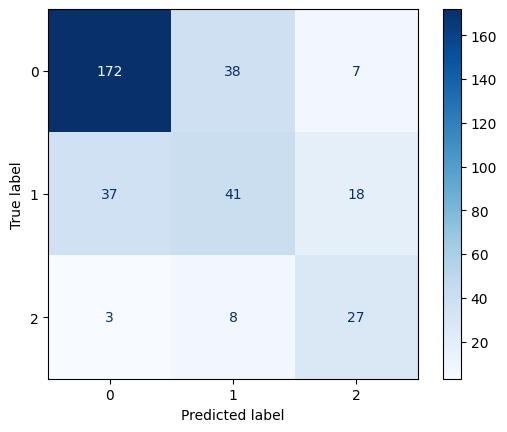

In [42]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = best_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = best_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




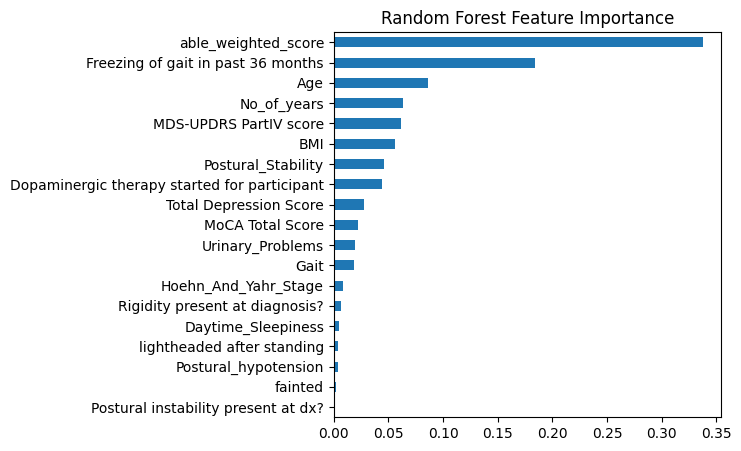

In [43]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


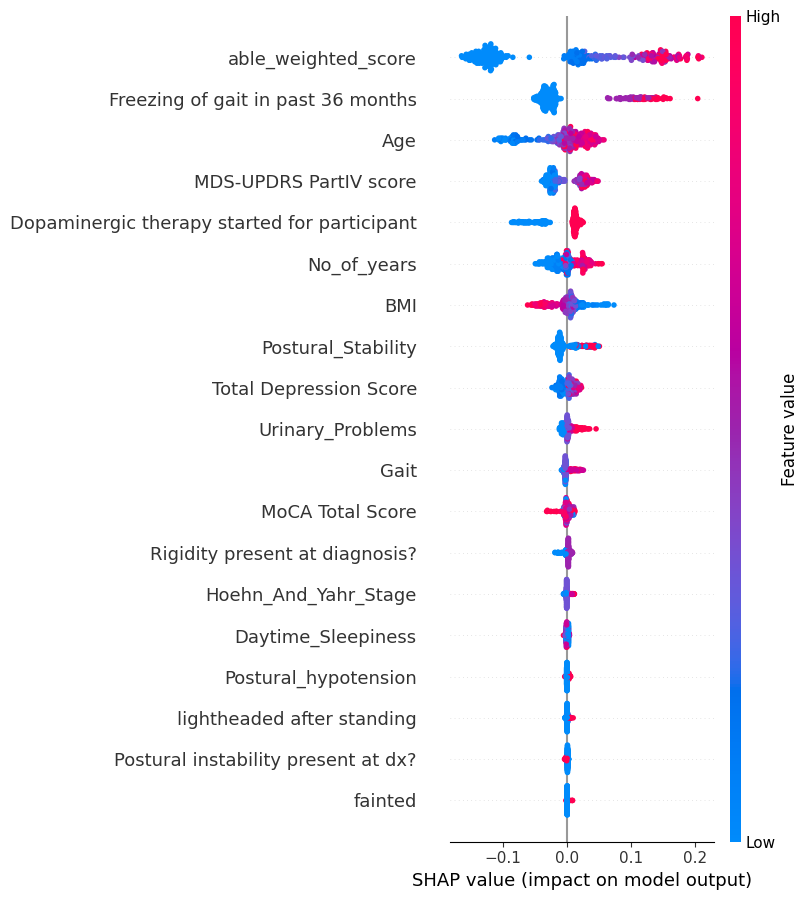

In [44]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)